# BrushCue Example: Desert Frame

<a href="https://colab.research.google.com/github/ditotechnologies/brushcue/blob/main/examples/desert_frame.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

You can use this tool online at https://www.brushcue.com/tools/desert-frame

In [ ]:
!pip install brushcue

[wgpu] using backend Metal — adapter 'Apple M5' (IntegratedGpu), driver ''


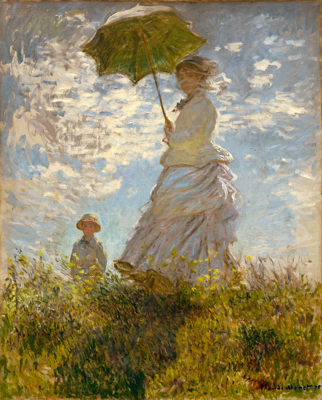

In [1]:
import io
from PIL import Image

import brushcue as bc

input_image = bc.Composition.monet_women_with_parasol()
base_grade = (
    input_image.r_g_b_curve(
        bc.Curve.gamma(0.91), bc.Curve.gamma(0.98), bc.Curve.gamma(1.08)
    )
    .l_curve(bc.Curve.s_curve(0.5, 1.15, 1.0, 1.0))
    .saturation_adjust(0.94)
)
graded = base_grade.color_transformer_shader(
    "let shadow_weight = smoothstep(0.45, 0.08, input.r);\nlet highlight_weight = smoothstep(0.52, 0.86, input.r);\nlet midtone_weight = 1.0 - max(shadow_weight, highlight_weight);\nlet a = input.g + 0.018 * midtone_weight - 0.018 * shadow_weight;\nlet b = input.b + 0.045 * midtone_weight - 0.028 * shadow_weight + 0.012 * highlight_weight;\nreturn vec4f(input.r, a, b, input.a);",
    "",
    bc.ColorRepresentation.oklab_a(),
    bc.ColorRepresentation.oklab_a(),
    bc.Dictionary.create(),
)
bounds = input_image.bounds()
filtered = graded.vignette(
    bc.Vector2f.from_components((bounds.width() / 2.0), (bounds.height() / 2.0)),
    (bounds.width() * 0.62),
    (bounds.height() * 0.5),
    (bounds.width() * 0.42),
    0.18,
).crop(bounds)
strength = 1.0
graph = (
    filtered.opacity_scales(strength)
    .blend_alpha(input_image, bc.Transform2.identity())
    .crop(bounds)
)

ctx = bc.Context()
composition = graph.execute(ctx)
data_bytes = composition.to_image_bytes(ctx)
img = Image.open(io.BytesIO(data_bytes))
img.thumbnail((400, 400))  # Remove this line for full resolution
img
